In [25]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F


# Фиксация seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [26]:
# Функция для логирования в runs.csv
def log_run(run_data, csv_path='artifacts/runs.csv'):
    df = pd.DataFrame([run_data])
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        df = pd.concat([df_existing, df], ignore_index=True)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    df.to_csv(csv_path, index=False)


# Функция для сохранения лучшей модели
def save_best_model(model, config, path='artifacts/best_classifier.pt',
                    config_path='artifacts/best_classifier_config.json'):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(model.state_dict(), path)
    import json
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)


# Визуализация батча
def show_batch(dataloader, title="Batch Examples"):
    images, labels = next(iter(dataloader))
    images = images[:8]
    labels = labels[:8]
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()
    for i, (img, lbl) in enumerate(zip(images, labels)):
        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())  # нормализация для отображения
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {lbl.item()}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Train base batch: torch.Size([16, 3, 32, 32])
Val batch: torch.Size([16, 3, 32, 32])


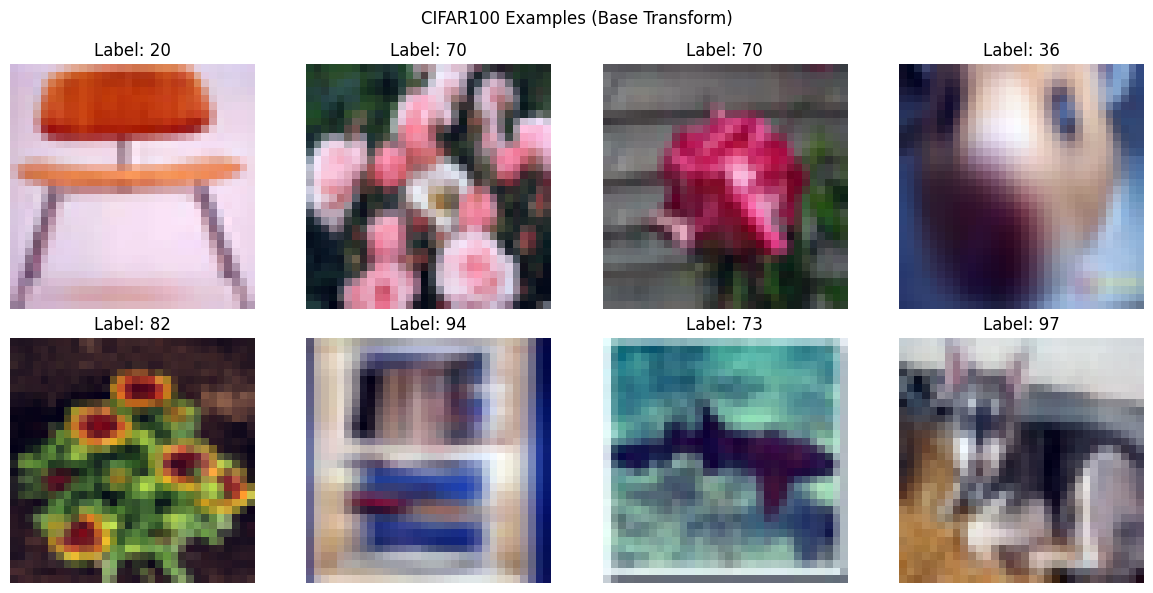

In [31]:
# Определяем transforms
mean = (0.5071, 0.4867, 0.4408)
std = (0.2675, 0.2565, 0.2761)

# Базовый transform (без аугментаций)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Аугментации для C2
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transform для pretrained ResNet18
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка датасета
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_base)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Для аугментаций используем отдельный датасет с transform_aug
train_aug_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_aug)
train_aug_subset = Subset(train_aug_dataset, train_subset.indices)

# Тестовый датасет
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_base)

# Создаём DataLoader'ы (batch_size=16)
batch_size = 16
train_loader_base = DataLoader(Subset(train_dataset, train_subset.indices), batch_size=batch_size, shuffle=True,
                               num_workers=2)
train_loader_aug = DataLoader(train_aug_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Для ResNet нужны 224x224 изображения
train_resnet_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_resnet)
train_resnet_subset = Subset(train_resnet_dataset, train_subset.indices)
train_resnet_loader = DataLoader(train_resnet_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_resnet_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_resnet_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Sanity check
print("Train base batch:", next(iter(train_loader_base))[0].shape)
print("Val batch:", next(iter(val_loader))[0].shape)
show_batch(train_loader_base, "CIFAR100 Examples (Base Transform)")

In [28]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [32]:
criterion = nn.CrossEntropyLoss()
epochs = 15
best_val_acc = 0.0
best_model_state = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# C1: simple-cnn-base
model_c1 = SimpleCNN().to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader_base, criterion, optimizer_c1, device)
    val_loss, val_acc = evaluate(model_c1, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(
        f"C1 Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c1.state_dict().copy()

# Сохраняем результаты
log_run({
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'base transform'
})

# C2: simple-cnn-aug
model_c2 = SimpleCNN().to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)
best_val_acc = 0.0
history_c2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_aug, criterion, optimizer_c2, device)
    val_loss, val_acc = evaluate(model_c2, val_loader, criterion, device)
    history_c2['train_loss'].append(train_loss)
    history_c2['train_acc'].append(train_acc)
    history_c2['val_loss'].append(val_loss)
    history_c2['val_acc'].append(val_acc)
    print(
        f"C2 Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c2.state_dict().copy()

log_run({
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'with augmentations'
})


C1 Epoch 1: train_loss=3.9190, train_acc=0.0948, val_loss=3.5052, val_acc=0.1567
C1 Epoch 2: train_loss=3.2910, train_acc=0.2026, val_loss=3.0949, val_acc=0.2397
C1 Epoch 3: train_loss=2.9729, train_acc=0.2645, val_loss=2.8809, val_acc=0.2874
C1 Epoch 4: train_loss=2.7505, train_acc=0.3095, val_loss=2.6987, val_acc=0.3237
C1 Epoch 5: train_loss=2.5981, train_acc=0.3402, val_loss=2.5806, val_acc=0.3517
C1 Epoch 6: train_loss=2.4724, train_acc=0.3668, val_loss=2.5382, val_acc=0.3584
C1 Epoch 7: train_loss=2.3700, train_acc=0.3876, val_loss=2.4784, val_acc=0.3653
C1 Epoch 8: train_loss=2.2859, train_acc=0.4068, val_loss=2.4281, val_acc=0.3822
C1 Epoch 9: train_loss=2.2147, train_acc=0.4178, val_loss=2.4082, val_acc=0.3852
C1 Epoch 10: train_loss=2.1535, train_acc=0.4359, val_loss=2.3690, val_acc=0.3902
C1 Epoch 11: train_loss=2.0911, train_acc=0.4492, val_loss=2.3729, val_acc=0.3907
C1 Epoch 12: train_loss=2.0424, train_acc=0.4589, val_loss=2.3588, val_acc=0.3991
C1 Epoch 13: train_loss=1

In [24]:
# C3: resnet18-head-only
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

from tqdm import tqdm


def train_one_epoch_add(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in tqdm(loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


model_c3 = models.resnet18(weights='IMAGENET1K_V1')

print(f"Model device: {next(model_c3.parameters()).device}")
print(f"Data device: {next(iter(train_resnet_loader))[0].device}")

for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 100)
model_c3 = model_c3.to(device)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=0.001)

best_val_acc = 0.0
history_c3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch_add(model_c3, train_resnet_loader, criterion, optimizer_c3, device)
    val_loss, val_acc = evaluate(model_c3, val_resnet_loader, criterion, device)
    history_c3['train_loss'].append(train_loss)
    history_c3['train_acc'].append(train_acc)
    history_c3['val_loss'].append(val_loss)
    history_c3['val_acc'].append(val_acc)
    print(
        f"C3 Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c3.state_dict().copy()

log_run({
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained, head only)',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'backbone frozen'
})

# C4: resnet18-finetune (разморозим layer4 и fc)
model_c4 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 100)
model_c4.fc.requires_grad = True
model_c4 = model_c4.to(device)
optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=0.001)

best_val_acc = 0.0
history_c4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch_add(model_c4, train_resnet_loader, criterion, optimizer_c4, device)
    val_loss, val_acc = evaluate(model_c4, val_resnet_loader, criterion, device)
    history_c4['train_loss'].append(train_loss)
    history_c4['train_acc'].append(train_acc)
    history_c4['val_loss'].append(val_loss)
    history_c4['val_acc'].append(val_acc)
    print(
        f"C4 Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c4.state_dict().copy()

log_run({
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'CIFAR100',
    'seed': 42,
    'model_summary': 'ResNet18 (pretrained, finetune layer4+fc)',
    'optimizer': 'Adam lr=0.001',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'layer4+fc unfrozen'
})

# Выбираем лучшую модель по best_val_accuracy из runs.csv
# В данном примере сохраним последнюю лучшую (C4)
save_best_model(model_c4, {
    'dataset': 'CIFAR100',
    'architecture': 'ResNet18',
    'transforms': 'resize224+normalize_imagenet',
    'hyperparams': {'lr': 0.001, 'optimizer': 'Adam', 'epochs': epochs, 'batch_size': batch_size},
    'seed': 42
})

Model device: cpu
Data device: cpu


Training: 100%|██████████| 2500/2500 [16:03<00:00,  2.59it/s]


C3 Epoch 1: train_loss=2.3930, train_acc=0.4014, val_loss=5.6385, val_acc=0.0708


Training: 100%|██████████| 2500/2500 [16:45<00:00,  2.49it/s]


C3 Epoch 2: train_loss=1.7681, train_acc=0.5226, val_loss=6.1950, val_acc=0.0678


...

C4 Epoch 13: train_loss=0.1260, train_acc=0.9603, val_loss=4.9990, val_acc=0.0306


Training: 100%|██████████| 2500/2500 [20:50<00:00,  2.00it/s]


C4 Epoch 14: train_loss=0.1070, train_acc=0.9660, val_loss=4.7686, val_acc=0.0321


Training: 100%|██████████| 2500/2500 [19:37<00:00,  2.12it/s]


C4 Epoch 15: train_loss=0.1086, train_acc=0.9653, val_loss=5.0939, val_acc=0.0318


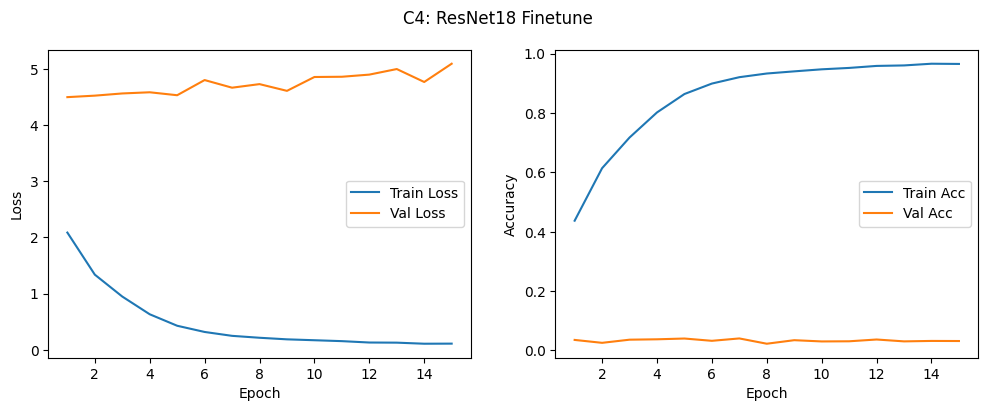

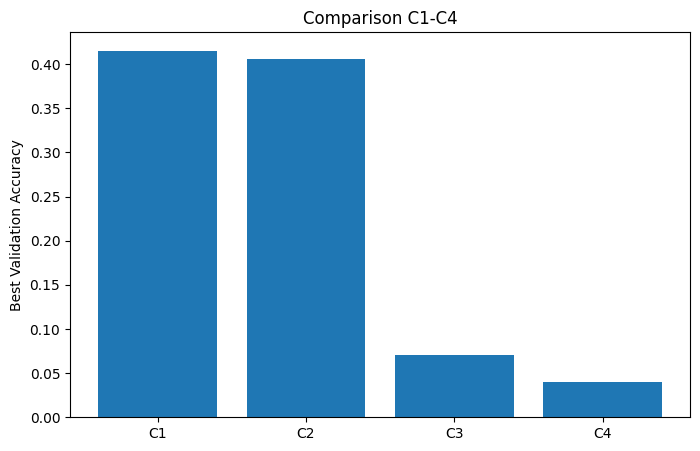

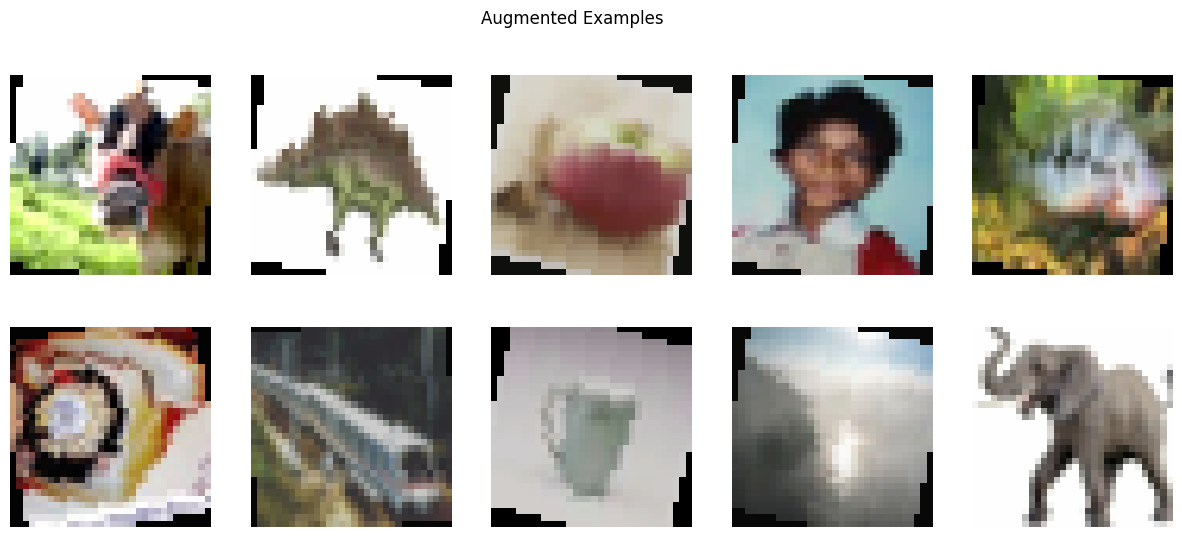

In [33]:
# Построим кривые обучения для лучшего прогона (C4)
os.makedirs('artifacts/figures', exist_ok=True)
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_c4['train_loss'], label='Train Loss')
plt.plot(epochs_range, history_c4['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_c4['train_acc'], label='Train Acc')
plt.plot(epochs_range, history_c4['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.suptitle('C4: ResNet18 Finetune')
plt.savefig('artifacts/figures/classification_curves_best.png')
plt.show()

# Сравнение лучших val_accuracy по C1-C4
exp_ids = ['C1', 'C2', 'C3', 'C4']
best_vals = []
for exp in exp_ids:
    df = pd.read_csv('artifacts/runs.csv')
    best_val = df[df['experiment_id'] == exp]['best_val_accuracy'].iloc[-1]
    best_vals.append(best_val)

plt.figure(figsize=(8, 5))
plt.bar(exp_ids, best_vals)
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison C1-C4')
plt.savefig('artifacts/figures/classification_compare.png')
plt.show()

# Визуализация аугментаций
train_aug_dataset = datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_aug)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img, _ = train_aug_dataset[i]
    img = img.permute(1, 2, 0).numpy()
    img = (img * std) + mean  # денормализация
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Augmented Examples')
plt.savefig('artifacts/figures/augmentations_preview.png')
plt.show()

100%|██████████| 792M/792M [08:31<00:00, 1.55MB/s] 
100%|██████████| 19.2M/19.2M [00:08<00:00, 2.13MB/s]


Batch images shape: torch.Size([8, 3, 224, 224])
Batch masks shape: torch.Size([8, 1, 224, 224])


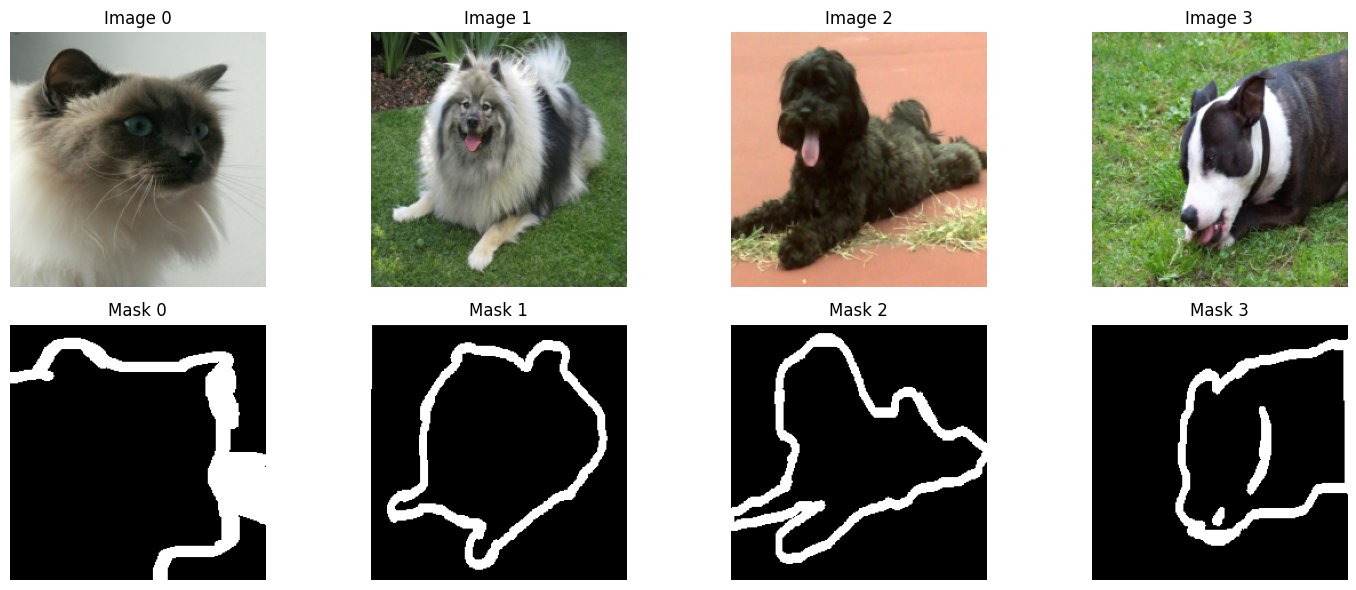

In [35]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# transforms для изображения (как для ResNet)
transform_img = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_mask = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='trainval', transform=transform_img, target_transform=transform_mask,
    target_types='segmentation', download=True
)
val_dataset = torchvision.datasets.OxfordIIITPet(
    root='./data', split='test', transform=transform_img, target_transform=transform_mask,
    target_types='segmentation', download=True
)


def make_binary_mask(mask):
    binary = (mask > 0.01).float()
    return binary


class BinaryPetDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        mask = make_binary_mask(mask)
        return img, mask


train_bin = BinaryPetDataset(train_dataset)
val_bin = BinaryPetDataset(val_dataset)

batch_size = 8
train_loader = DataLoader(train_bin, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_bin, batch_size=batch_size, shuffle=False, num_workers=0)

# Sanity check
images, masks = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch masks shape:", masks.shape)


# Покажем несколько примеров
def show_seg_batch(images, masks, num=4):
    fig, axes = plt.subplots(2, num, figsize=(15, 6))
    for i in range(num):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Image {i}")
        axes[0, i].axis('off')
        mask = masks[i].squeeze().numpy()
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f"Mask {i}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


show_seg_batch(images, masks)

In [40]:
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50


def create_deeplabv3_binary(num_classes=1):
    model = deeplabv3_resnet50(pretrained=True, progress=True)
    model.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1, stride=1)
    if model.aux_classifier is not None:
        model.aux_classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1, stride=1)
    return model

model_seg = create_deeplabv3_binary(num_classes=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_seg = model_seg.to(device)
model_seg.eval()

print(f"Model loaded on {device}")


model_seg = create_deeplabv3_binary(num_classes=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_seg = model_seg.to(device)
model_seg.eval()

print(f"Model loaded on {device}")

import numpy as np
from scipy import ndimage


def postprocess_basic(pred_logits):
    probs = torch.sigmoid(pred_logits)  # [B,1,H,W]
    masks = (probs > 0.5).float()
    return masks


def postprocess_clean_components(pred_logits, min_size=100):
    probs = torch.sigmoid(pred_logits)
    masks = (probs > 0.5).float().cpu().numpy().squeeze(1)  # [B,H,W]
    cleaned = []
    for mask in masks:
        # удаляем маленькие компоненты
        labeled, num_features = ndimage.label(mask)
        sizes = ndimage.sum(mask, labeled, range(num_features + 1))
        mask_clean = np.zeros_like(mask)
        for i in range(1, num_features + 1):
            if sizes[i] >= min_size:
                mask_clean[labeled == i] = 1
        cleaned.append(mask_clean)
    cleaned = np.array(cleaned)
    return torch.from_numpy(cleaned).float().unsqueeze(1).to(pred_logits.device)


def compute_iou(pred_mask, true_mask):
    pred = (pred_mask > 0.5).float().view(pred_mask.size(0), -1)
    true = (true_mask > 0.5).float().view(true_mask.size(0), -1)
    intersection = (pred * true).sum(dim=1)
    union = pred.sum(dim=1) + true.sum(dim=1) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()


def compute_pixel_metrics(pred_mask, true_mask):
    pred = (pred_mask > 0.5).float().view(pred_mask.size(0), -1)
    true = (true_mask > 0.5).float().view(true_mask.size(0), -1)
    tp = (pred * true).sum(dim=1)
    fp = (pred * (1 - true)).sum(dim=1)
    fn = ((1 - pred) * true).sum(dim=1)
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    return precision.mean().item(), recall.mean().item()


def evaluate_segmentation(model, loader, postprocess_func, device='cpu'):
    model.eval()
    total_iou = 0.0
    total_prec = 0.0
    total_rec = 0.0
    num_batches = 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)['out']
            pred_masks = postprocess_func(outputs)
            iou = compute_iou(pred_masks, masks)
            prec, rec = compute_pixel_metrics(pred_masks, masks)
            total_iou += iou
            total_prec += prec
            total_rec += rec
            num_batches += 1
    return total_iou / num_batches, total_prec / num_batches, total_rec / num_batches

/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/soldatov_a/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded on cpu
Model loaded on cpu


Evaluating V1...
V1: mIoU=0.1583, Precision=0.1787, Recall=0.8151


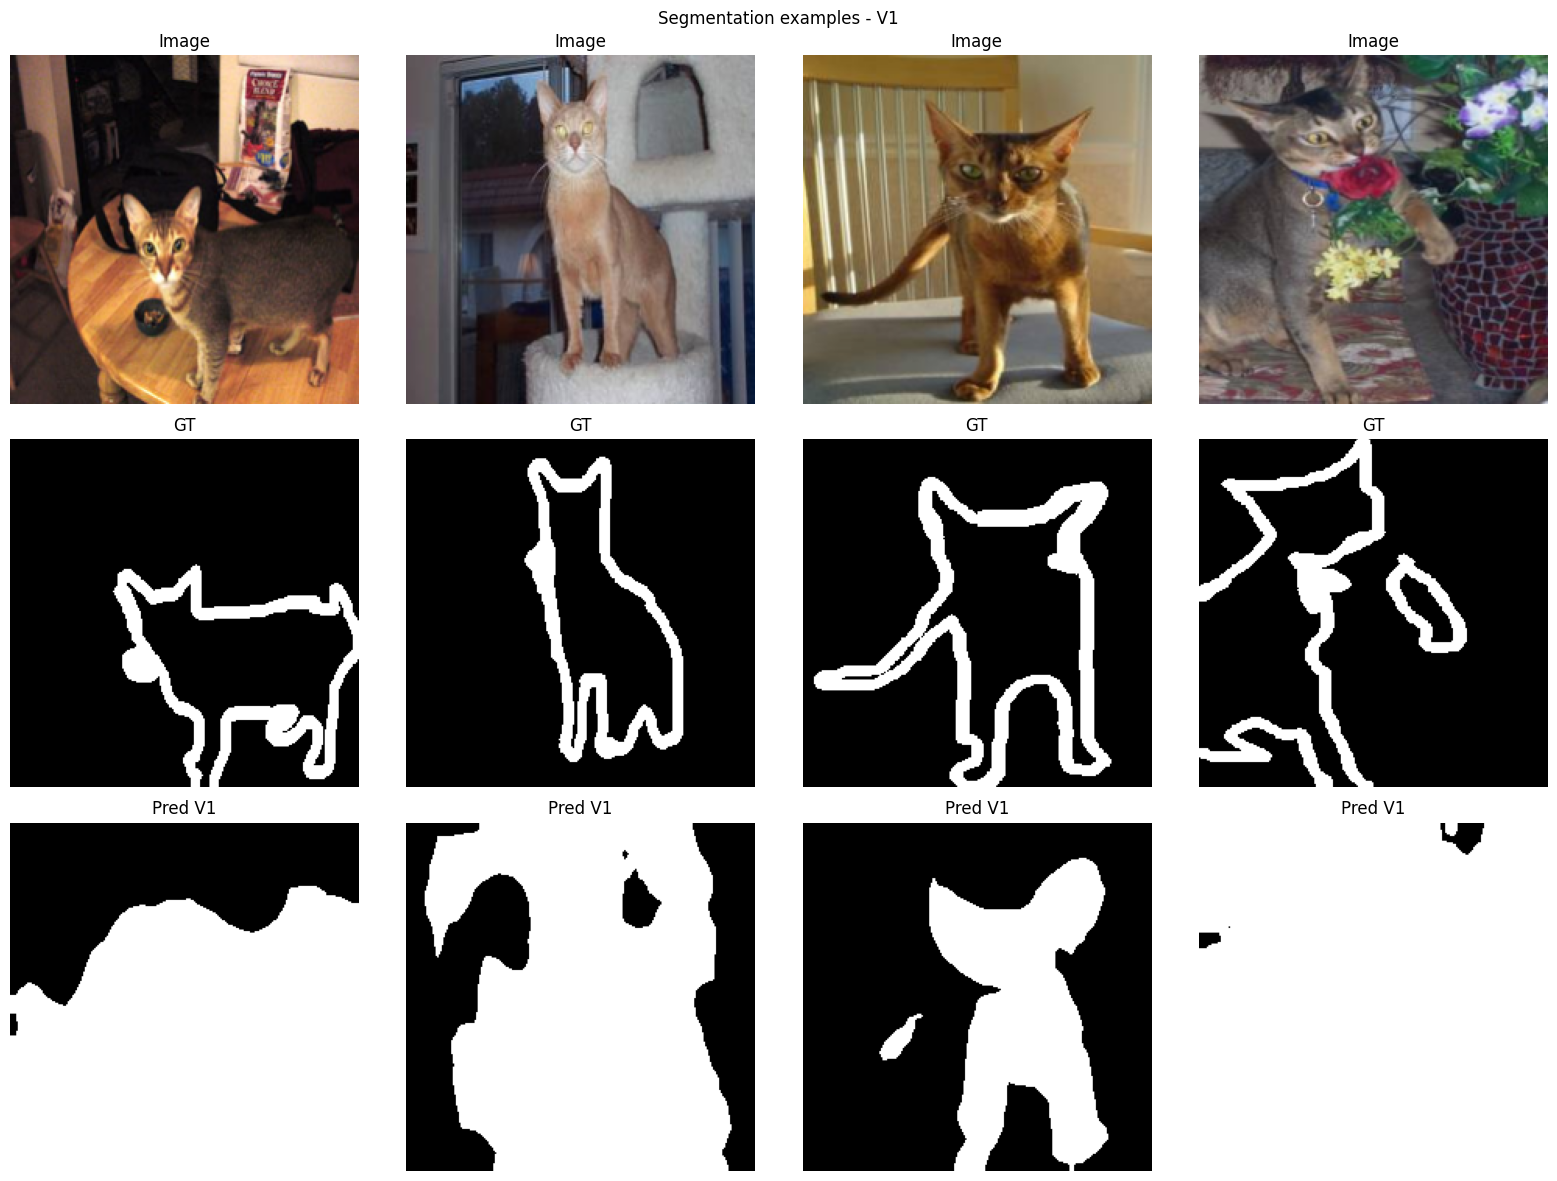

Evaluating V2...
V2: mIoU=0.1583, Precision=0.1810, Recall=0.8149


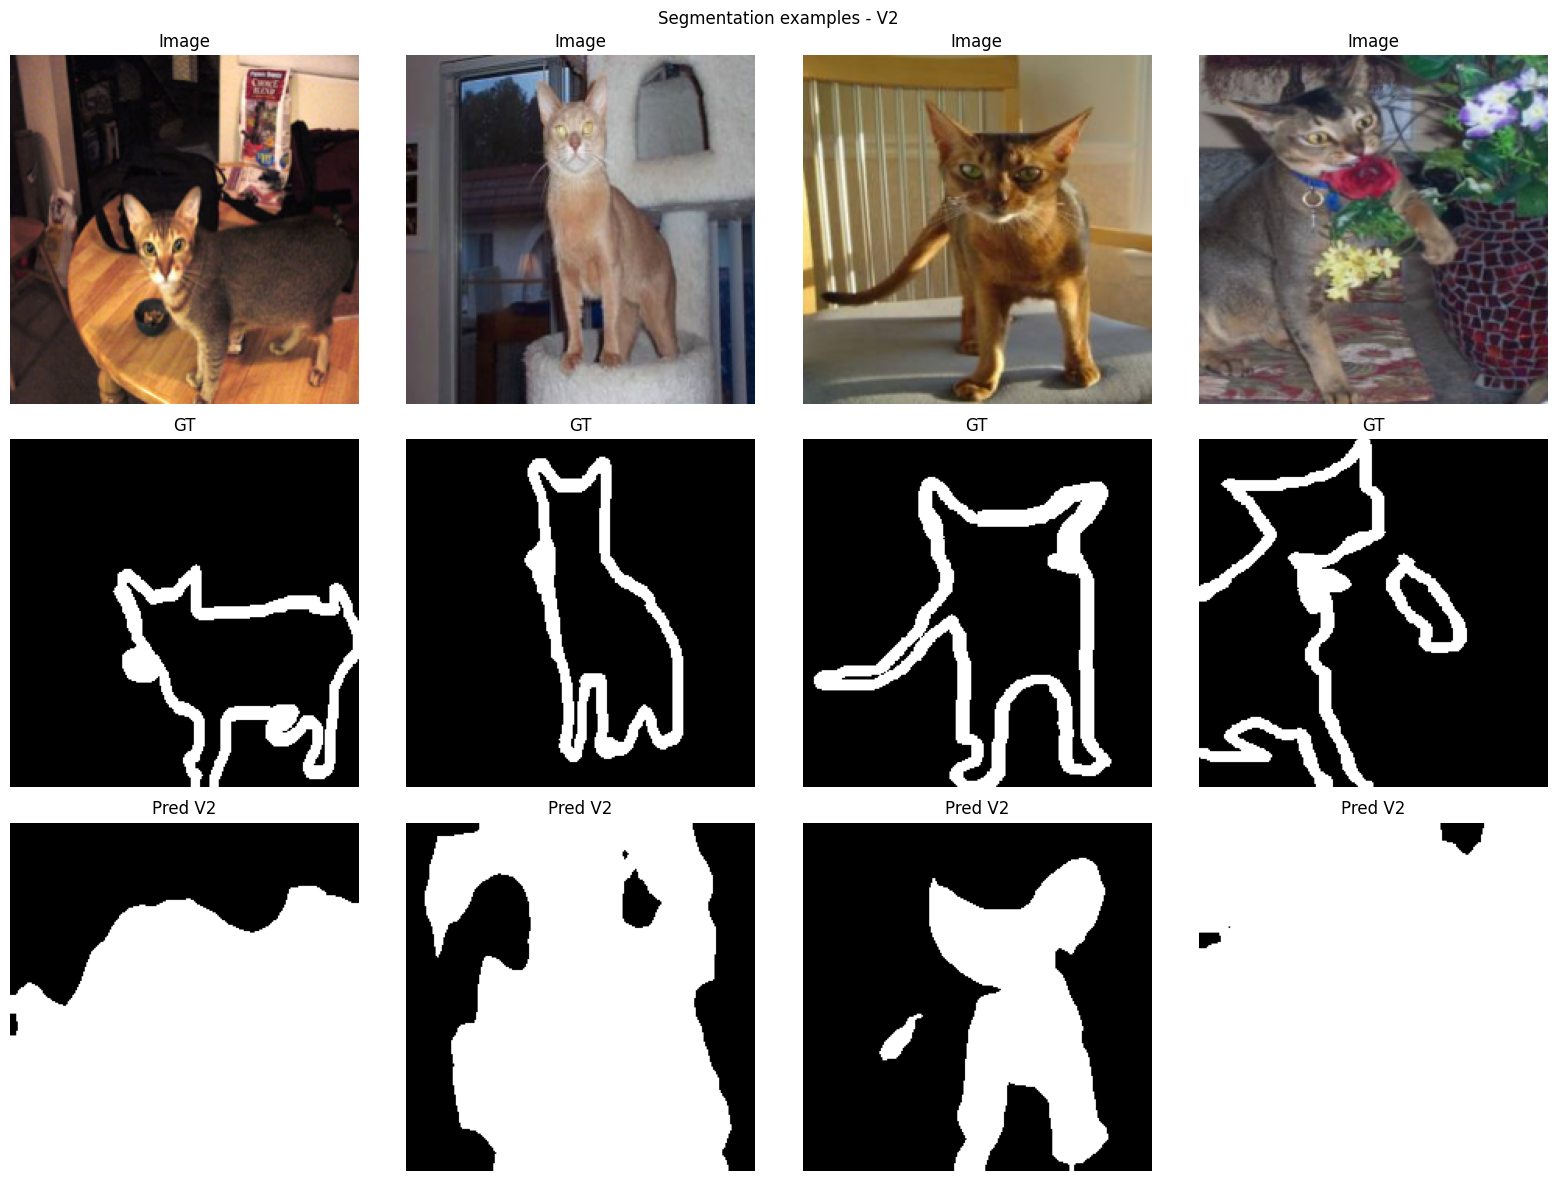

/var/folders/5h/zshkg9_j4z95z0wj2l0ghng00000gn/T/ipykernel_29755/3931852629.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([existing, df], ignore_index=True)


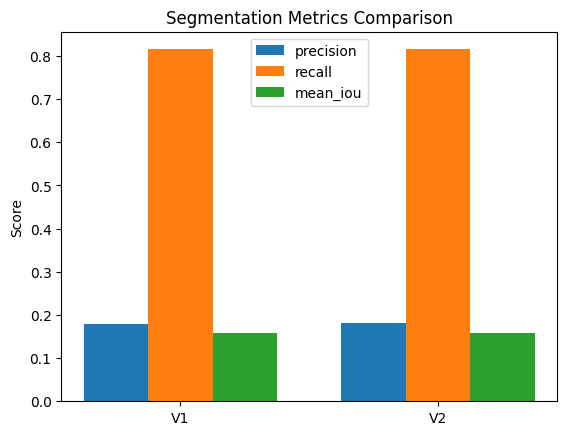

All done. Results saved to runs.csv and figures.


In [41]:
import pandas as pd
import os
from tqdm import tqdm

# Создаём папки
os.makedirs('artifacts/figures', exist_ok=True)

# Определяем постобработки
postprocesses = {
    'V1': postprocess_basic,
    'V2': lambda x: postprocess_clean_components(x, min_size=100)
}

results = []

for name, post_func in postprocesses.items():
    print(f"Evaluating {name}...")
    mean_iou, mean_prec, mean_rec = evaluate_segmentation(model_seg, val_loader, post_func, device)
    print(f"{name}: mIoU={mean_iou:.4f}, Precision={mean_prec:.4f}, Recall={mean_rec:.4f}")

    # Сохраняем в runs.csv
    log_data = {
        'experiment_id': name,
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3_ResNet50_binary',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': mean_prec,
        'recall': mean_rec,
        'mean_iou': mean_iou,
        'notes': f'postprocessing: {name}'
    }
    results.append(log_data)

    # Визуализация примеров для этого режима
    model_seg.eval()
    images, masks = next(iter(val_loader))
    images = images.to(device)
    with torch.no_grad():
        outputs = model_seg(images)['out']
        pred_masks = post_func(outputs).cpu()
    images = images.cpu()
    masks = masks.cpu()

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for i in range(4):
        # Изображение
        img = images[i].permute(1,2,0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[0, i].imshow(img)
        axes[0, i].set_title("Image")
        axes[0, i].axis('off')
        # GT
        gt = masks[i].squeeze().numpy()
        axes[1, i].imshow(gt, cmap='gray')
        axes[1, i].set_title("GT")
        axes[1, i].axis('off')
        # Pred
        pred = pred_masks[i].squeeze().numpy()
        axes[2, i].imshow(pred, cmap='gray')
        axes[2, i].set_title(f"Pred {name}")
        axes[2, i].axis('off')
    plt.suptitle(f"Segmentation examples - {name}")
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/segmentation_examples_{name}.png')
    plt.show()

# Сохраняем все результаты в runs.csv
df = pd.DataFrame(results)
csv_path = 'artifacts/runs.csv'
if os.path.exists(csv_path):
    existing = pd.read_csv(csv_path)
    df = pd.concat([existing, df], ignore_index=True)
df.to_csv(csv_path, index=False)

# Построение графика метрик для сравнения
metrics = ['precision', 'recall', 'mean_iou']
x = np.arange(len(results))
width = 0.25
fig, ax = plt.subplots()
for i, metric in enumerate(metrics):
    values = [r[metric] for r in results]
    ax.bar(x + i*width, values, width, label=metric)
ax.set_xticks(x + width)
ax.set_xticklabels([r['experiment_id'] for r in results])
ax.set_ylabel('Score')
ax.set_title('Segmentation Metrics Comparison')
ax.legend()
plt.savefig('artifacts/figures/segmentation_metrics.png')
plt.show()

print("All done. Results saved to runs.csv and figures.")